In [104]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [105]:
#import file
df = pd.read_csv('Car_price_2024.csv')

In [106]:
df.head()

,Model,Year,Fuel_Type,Transmission,DoorsNum,Condition,Color,Cruise,Leather_Seats,Heated_Seats,...,Price,Cylinder_Numbers,Credit_History,Engine_Size,Weight,carlength,carwidth,monthly_mileage,peakrpm,Estimated_Mileage
0,Nissan Altima,2007,Petrol,Manual,4.0,Fair,Brown,No,No,No,...,8005.469674,two,0.004967,1.655688,3170.460434,179.1,68.1,3020.474750,6000,36245.697
1,Toyota Corolla,2019,Electric,Manual,4.0,Excellent,Beige,Yes,No,Yes,...,25385.241860,two,-0.001383,2.696626,3543.00629,182.1,60.0,894.742606,4689,10736.91127
2,Honda CR-V,2004,Petrol,Manual,4.0,Fair,Brown,No,No,No,...,6553.601733,three,0.006477,1.642471,3125.542396,161.0,67.5,3496.160436,5190,41953.92523
3,Toyota Corolla,2020,Electric,Manual,4.0,Good,Brown,Yes,Yes,Yes,...,24381.083350,three,0.015230,2.044309,3340.060049,169.7,65.2,1037.247974,5720,12446.97569
4,Toyota Tundra,2017,Hybrid,Automatic,4.0,Good,Brown,Yes,No,No,...,28357.830640,five,-0.002342,2.586011,3847.825597,176.0,68.1,880.045753,4559,10560.54904


In [107]:
df['Safety'].value_counts()

Safety
4 stars              520
Not rated/Unknown    430
1 star               375
2 stars              327
5 stars              285
3 stars              191
4                    102
Name: count, dtype: int64

In [108]:
# Drop rows with missing target
df = df.dropna(subset=["Price"])

In [109]:
# Create 'Car_Age' from 'Year'
current_year = datetime.datetime.now().year
df["Car_Age"] = current_year - df["Year"]
df.drop(columns=["Year"], inplace=True)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2230 entries, 0 to 2229
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Model              2230 non-null   object 
 1   Fuel_Type          2227 non-null   object 
 2   Transmission       2223 non-null   object 
 3   DoorsNum           2223 non-null   float64
 4   Condition          2230 non-null   object 
 5   Color              2228 non-null   object 
 6   Cruise             2230 non-null   object 
 7   Leather_Seats      2230 non-null   object 
 8   Heated_Seats       2230 non-null   object 
 9   Navigation         2230 non-null   object 
 10  Owners             2230 non-null   int64  
 11  Insurance          2230 non-null   object 
 12  Service_History    2230 non-null   object 
 13  Safety             2230 non-null   object 
 14  Premium_Sound      2230 non-null   object 
 15  Multimedia         2230 non-null   object 
 16  Bluetooth          2230 

In [111]:
df['TAge'].unique()

array(['3', '1', '5', '2', '4', '50', '4 years'], dtype=object)

#**Initially clean data**

In [113]:
# Define feature groups
categorical_cols = [
    "Model", "Fuel_Type", "Transmission", "Condition", "Color", "Cruise", "Leather_Seats",
    "Heated_Seats", "Navigation", "Insurance", "Service_History", "Safety", "Premium_Sound",
    "Multimedia", "Bluetooth", "Wheel", "Sunroof", "Cylinder_Numbers"
    ,  "DoorsNum"
]

numeric_cols = [
    "Engine_Size", "Weight", "monthly_mileage", "Estimated_Mileage", "Credit_History",
    "Car_Age", "TAge", "carlength",  "peakrpm","Owners", "Warranty",
]

**Clean data for numeric collumns**

In [115]:
# Clean numeric columns: remove invalid entries and convert to float
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("km", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("-", pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [116]:
df[numeric_cols].dtypes

Engine_Size          float64
Weight               float64
monthly_mileage      float64
Estimated_Mileage    float64
Credit_History       float64
Car_Age                int64
TAge                 float64
carlength            float64
peakrpm                int64
Owners                 int64
Warranty               int64
dtype: object

- Clean data for TAge col

In [118]:
df['TAge'].unique()

array([ 3.,  1.,  5.,  2.,  4., 50., nan])

In [119]:
# replace invalide entries in TAge

df['TAge'] = df['TAge'].replace(50, 5)
df['TAge'].unique()

array([ 3.,  1.,  5.,  2.,  4., nan])

- Clean data for Owners

In [121]:
df['Owners'].unique()

array([ 2,  1,  4,  3, 22, 44,  0], dtype=int64)

In [122]:
# replace invalid entries in Owners col
df['Owners'] = df['Owners'].replace({22 : 2, 44 : 4})
df['Owners'].unique()

array([2, 1, 4, 3, 0], dtype=int64)

**Clean data for categorical collumns**

In [124]:
df[categorical_cols].dtypes

Model                object
Fuel_Type            object
Transmission         object
Condition            object
Color                object
Cruise               object
Leather_Seats        object
Heated_Seats         object
Navigation           object
Insurance            object
Service_History      object
Safety               object
Premium_Sound        object
Multimedia           object
Bluetooth            object
Wheel                object
Sunroof              object
Cylinder_Numbers     object
DoorsNum            float64
dtype: object

In [125]:
# check unique value of categorical_cols
for col in categorical_cols:
  print(f"Unique values for {col}: {df[col].unique()}")

Unique values for Model: ['Nissan Altima' 'Toyota Corolla' 'Honda CR-V' 'Toyota Tundra'
 'Ford Fusion' 'Ford Escape' 'Nissan GT-R' 'Chevrolet Volt' 'Toyota Prius'
 'Chevrolet Bolt' 'Chevrolet Impala' 'Honda Pilot' 'Toyota Camry'
 'Toyota Camary' 'Nissan Juke' 'Nissan Murano' 'Chevrolet Corvette'
 'Honda Accord' 'Chevrolet Camaro' 'Nissan 350Z' 'Chevrolet Sonic'
 'Ford Mustang' 'Honda Fit' 'Nissan Titan']
Unique values for Fuel_Type: ['Petrol' 'Electric' 'Hybrid' nan 'Petroll']
Unique values for Transmission: ['Manual' 'Automatic' nan 'Na' 'AutoNamatic']
Unique values for Condition: ['Fair' 'Excellent' 'Good' 'Excellent!' 'Exc']
Unique values for Color: ['Brown' 'Beige' 'Black' 'Yellow' 'Silver' 'White' 'Brwn' nan]
Unique values for Cruise: ['No' 'Yes' 'Y']
Unique values for Leather_Seats: ['No' 'Yes']
Unique values for Heated_Seats: ['No' 'Yes']
Unique values for Navigation: ['No' 'Yes']
Unique values for Insurance: ['Third Party' 'No insurance' 'Collision' 'Comprehensive' 'No' '3rd Pa

In [126]:
# Apply the specified replacements to the DataFrame
df['Fuel_Type'] = df['Fuel_Type'].replace('Petroll', 'Petrol')
df['Transmission'] = df['Transmission'].replace({
    'AutoNamatic': 'Automatic',
    'Na' :'',
})
df['Condition'] = df['Condition'].replace('Exc', 'Excellent')
df['Color'] = df['Color'].replace('Brwn', 'Brown')
df['Insurance'] = df['Insurance'].replace('Y', 'Yes')
df['Service_History'] = df['Service_History'].replace({
    '3rd Party': 'Third Party',
    'Partital': 'Partial Service',
    'Full': 'Full Service'
})
df['Safety'] = df['Safety'].replace('4', '4 stars')
df['Cylinder_Numbers'] = df['Cylinder_Numbers'].replace({
    '3' : ' three',
    '4' : ' four',
    '5' : ' five',
})
df['DoorsNum'] = df['DoorsNum'].replace({
    22 : 2,
    44 : 4,
    20 : 2,
    40 : 4,
})

In [127]:
for col in categorical_cols:
  print(f"Unique values for {col}: {df[col].unique()}")

Unique values for Model: ['Nissan Altima' 'Toyota Corolla' 'Honda CR-V' 'Toyota Tundra'
 'Ford Fusion' 'Ford Escape' 'Nissan GT-R' 'Chevrolet Volt' 'Toyota Prius'
 'Chevrolet Bolt' 'Chevrolet Impala' 'Honda Pilot' 'Toyota Camry'
 'Toyota Camary' 'Nissan Juke' 'Nissan Murano' 'Chevrolet Corvette'
 'Honda Accord' 'Chevrolet Camaro' 'Nissan 350Z' 'Chevrolet Sonic'
 'Ford Mustang' 'Honda Fit' 'Nissan Titan']
Unique values for Fuel_Type: ['Petrol' 'Electric' 'Hybrid' nan]
Unique values for Transmission: ['Manual' 'Automatic' nan '']
Unique values for Condition: ['Fair' 'Excellent' 'Good' 'Excellent!']
Unique values for Color: ['Brown' 'Beige' 'Black' 'Yellow' 'Silver' 'White' nan]
Unique values for Cruise: ['No' 'Yes' 'Y']
Unique values for Leather_Seats: ['No' 'Yes']
Unique values for Heated_Seats: ['No' 'Yes']
Unique values for Navigation: ['No' 'Yes']
Unique values for Insurance: ['Third Party' 'No insurance' 'Collision' 'Comprehensive' 'No' '3rd Party']
Unique values for Service_History

In [128]:
#  Encode categorical columns with LabelEncoder
df_encoded = df.copy()
label_encoders = {}
for col in categorical_cols:
  label_encoders[col] = LabelEncoder()
  df_encoded[col] = label_encoders[col].fit_transform(df_encoded[col])

#**feature selection**

In [130]:
correlation = df_encoded[["Estimated_Mileage", "monthly_mileage"]].corr()
print(correlation)

                   Estimated_Mileage  monthly_mileage
Estimated_Mileage                1.0              1.0
monthly_mileage                  1.0              1.0


Top 10 Important Features (excluding 'monthly_mileage'):

              Feature  Importance
21  Estimated_Mileage    0.936014
4               Color    0.011345
0               Model    0.009080
27             Owners    0.005310
19        Engine_Size    0.005065
11             Safety    0.004403
20             Weight    0.003283
10    Service_History    0.002343
9           Insurance    0.002324
23            Car_Age    0.002254
26            peakrpm    0.002236
22     Credit_History    0.002110
25          carlength    0.001942
17   Cylinder_Numbers    0.001705
28           Warranty    0.001702


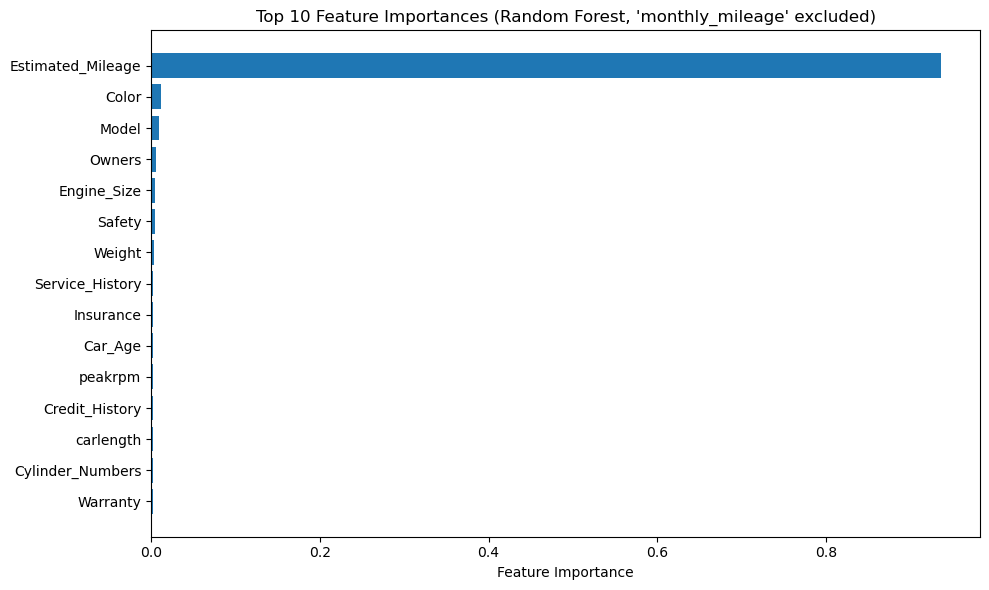

In [131]:
# Remove 'monthly_mileage' from features
X = df_encoded[[col for col in (categorical_cols + numeric_cols) if col != "monthly_mileage"]]
y = df_encoded["Price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Select top 10 features
top_10_features = importance_df.head(15)

print("Top 10 Important Features (excluding 'monthly_mileage'):\n")
print(top_10_features)

# Plot top 10 features
plt.figure(figsize=(10, 6))
plt.barh(top_10_features["Feature"][::-1], top_10_features["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (Random Forest, 'monthly_mileage' excluded)")
plt.tight_layout()
plt.show()


#Univariate analysis

In [133]:
# covert dtype of categorical_cols into object

for col in categorical_cols:
    df[col] = df[col].astype('object')

df[categorical_cols].dtypes

Model               object
Fuel_Type           object
Transmission        object
Condition           object
Color               object
Cruise              object
Leather_Seats       object
Heated_Seats        object
Navigation          object
Insurance           object
Service_History     object
Safety              object
Premium_Sound       object
Multimedia          object
Bluetooth           object
Wheel               object
Sunroof             object
Cylinder_Numbers    object
DoorsNum            object
dtype: object

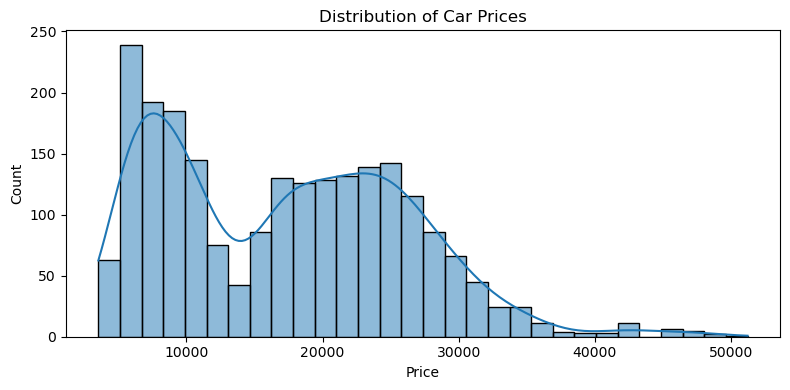

In [134]:
# Plot distribution of Price
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Price", kde=True, bins=30)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Right-skewed distribution: Most cars are priced under $25,000, with a long tail extending toward higher prices.

Multi-modal: Several price peaks suggest distinct market segments (economy, mid-range, premium cars).

Most frequent price range: Around 7000-1000

Outliers: A few high-priced vehicles (> 40,000) are rare and likely premium models.

In [136]:
# Define numeric columns to plot
numeric_cols = [
    "Estimated_Mileage", "Engine_Size", "Weight",
     "Car_Age"
]

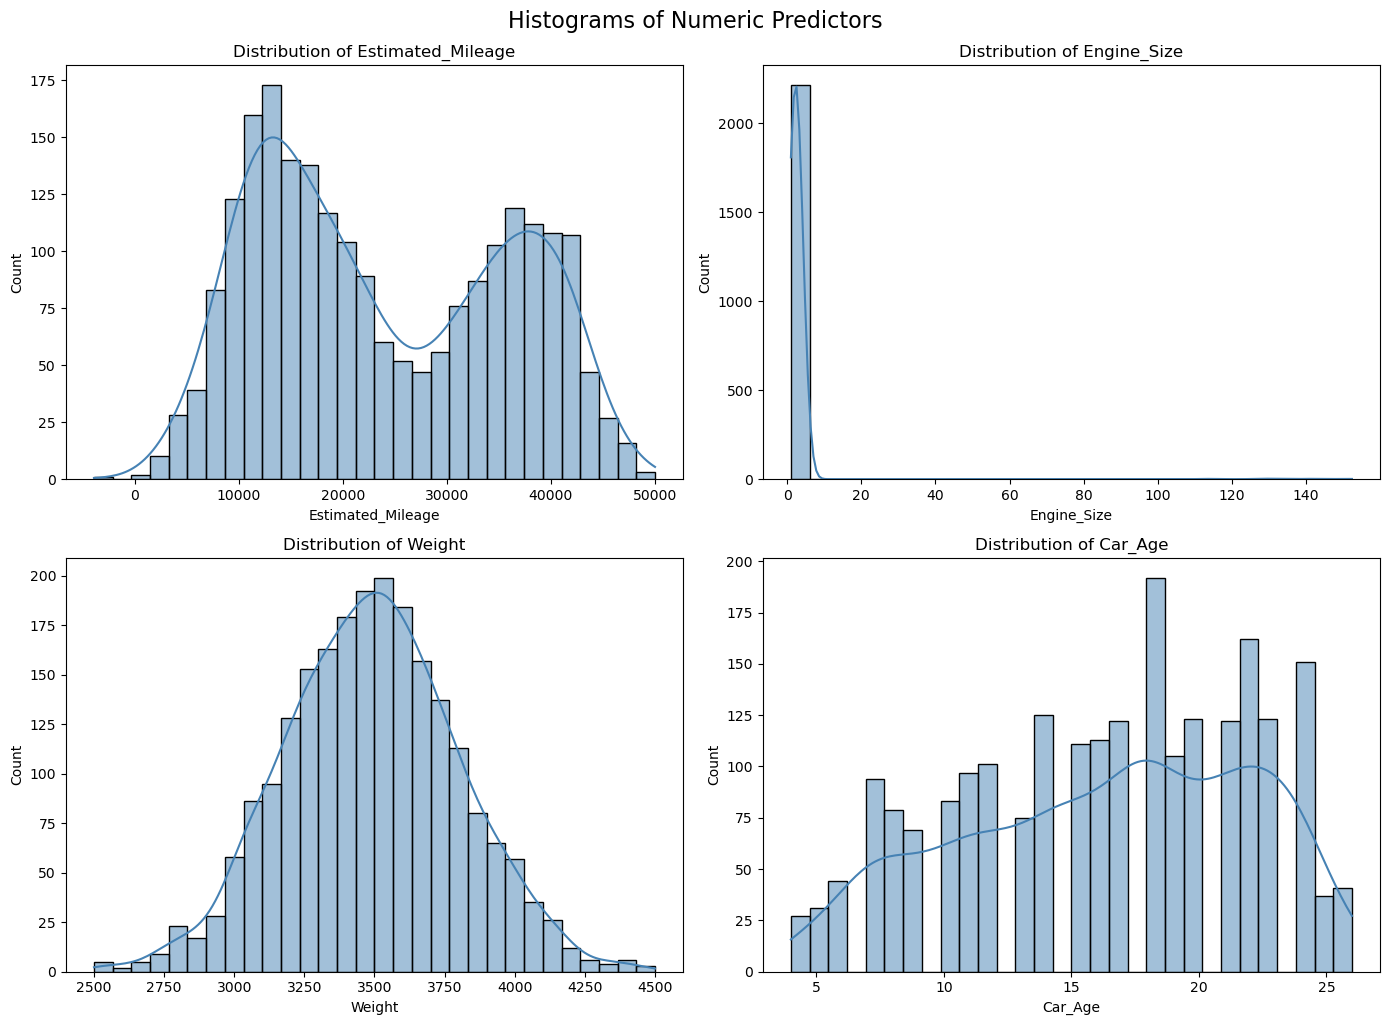

In [137]:
# Drop rows with NaNs in these columns
df_num = df[numeric_cols].dropna()

# Plot 2x2 grid of histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df_num, x=col, kde=True, bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.suptitle("Histograms of Numeric Predictors", fontsize=16, y=1.02)

# Remove any unused axes
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.show()

### **1. Estimated_Mileage**
* **Bimodal distribution:** The two distinct peaks suggest two major groups of cars, likely representing lower-mileage and higher-mileage vehicles.
* The peaks are centered at approximately 15,000 and 38,000 miles.

### **2. Engine_Size**
* **Extremely right-skewed:** The vast majority of cars have a very small engine size (under 10), with a long tail of sparse values.
* This shape strongly suggests the presence of outliers or data errors that need to be addressed.

### **3. Weight**
* **Nearly normal distribution:** The data forms a symmetrical bell curve.
* It is centered around a typical weight of approximately 3,500 lbs.
* This predictable distribution makes it a reliable feature for modeling without needing transformation.

### **4. Car_Age**
* There is a **wide spread** of ages, ranging from roughly 3 to 25 years.
* The distribution is fairly uniform, indicating a diverse mix of vehicle ages.

---
### **Recommendations**
* **Engine_Size** requires outlier treatment (e.g., capping or removal) before being used in a model.
* **Estimated_Mileage** could be segmented into two groups (e.g., "low" and "high" mileage) based on its bimodal nature to create a useful categorical feature.
* **Weight** is statistically well-behaved and can be used as-is.

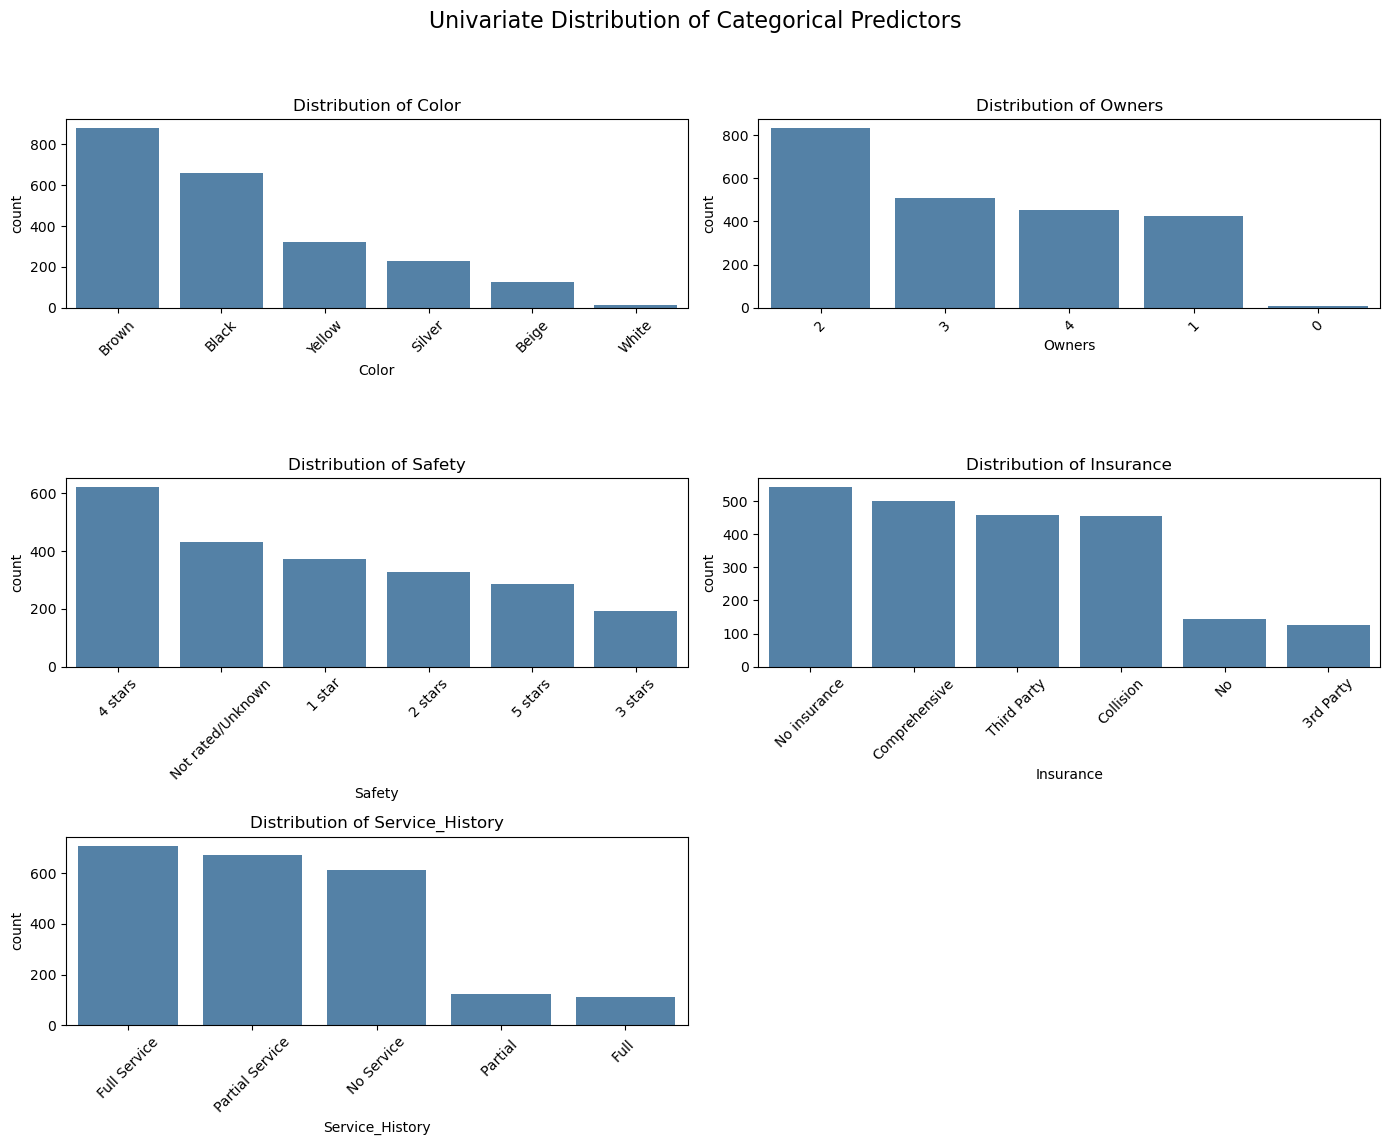

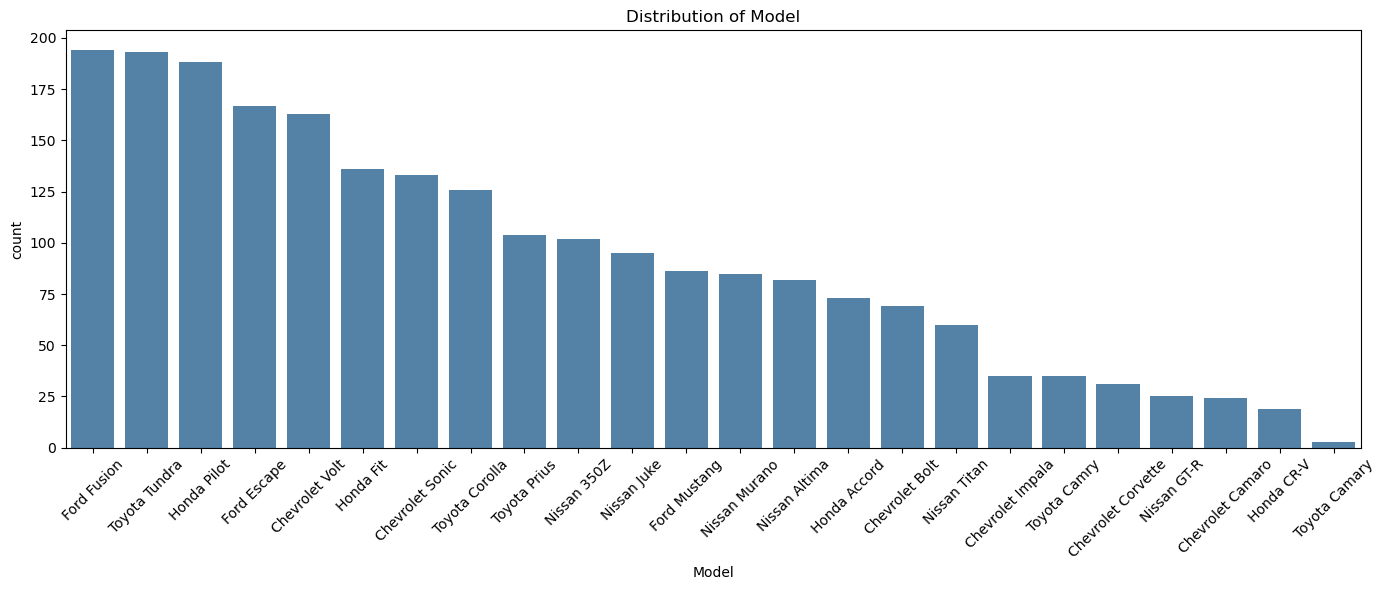

In [139]:
non_numeric_cols = ["Color", "Owners", "Safety", "Insurance", "Service_History"]
model_col = "Model"

# Drop missing values
df_clean = df[non_numeric_cols + [model_col]].dropna()

# --- 3x2 grid for other categorical features ---
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(non_numeric_cols):
    sns.countplot(x=df_clean[col], ax=axes[i], color='steelblue', order=df_clean[col].value_counts().index)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Remove any unused axes
for j in range(len(non_numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Univariate Distribution of Categorical Predictors", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Separate plot for Model ---
plt.figure(figsize=(14, 6))
sns.countplot(x=df_clean[model_col], order=df_clean[model_col].value_counts().index, color='steelblue')
plt.title("Distribution of Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. Estimated_Mileage
The distribution is bimodal, suggesting two major groups of cars, likely representing lower-mileage and higher-mileage vehicles. The peaks are centered at approximately 15,000 and 38,000 miles.

2. Engine_Size
The data is extremely right-skewed. The vast majority of cars have a very small engine size (under 10), with a long tail of sparse values. This shape strongly suggests the presence of outliers or data errors.

3. Weight
The data forms a nearly normal distribution (a symmetrical bell curve). It is centered around a typical weight of approximately 3,500 lbs. This predictable distribution makes it a reliable feature for modeling.

4. Car_Age
There is a wide and fairly uniform spread of ages, ranging from roughly 3 to 25 years, indicating a diverse mix of vehicle ages.

Recommendations
Engine_Size requires outlier treatment (e.g., capping or removal) before being used in a model.

Estimated_Mileage could be segmented into "low" and "high" mileage groups to create a useful categorical feature.

Weight is statistically well-behaved and can be used as-is.

# Bivariate analysis

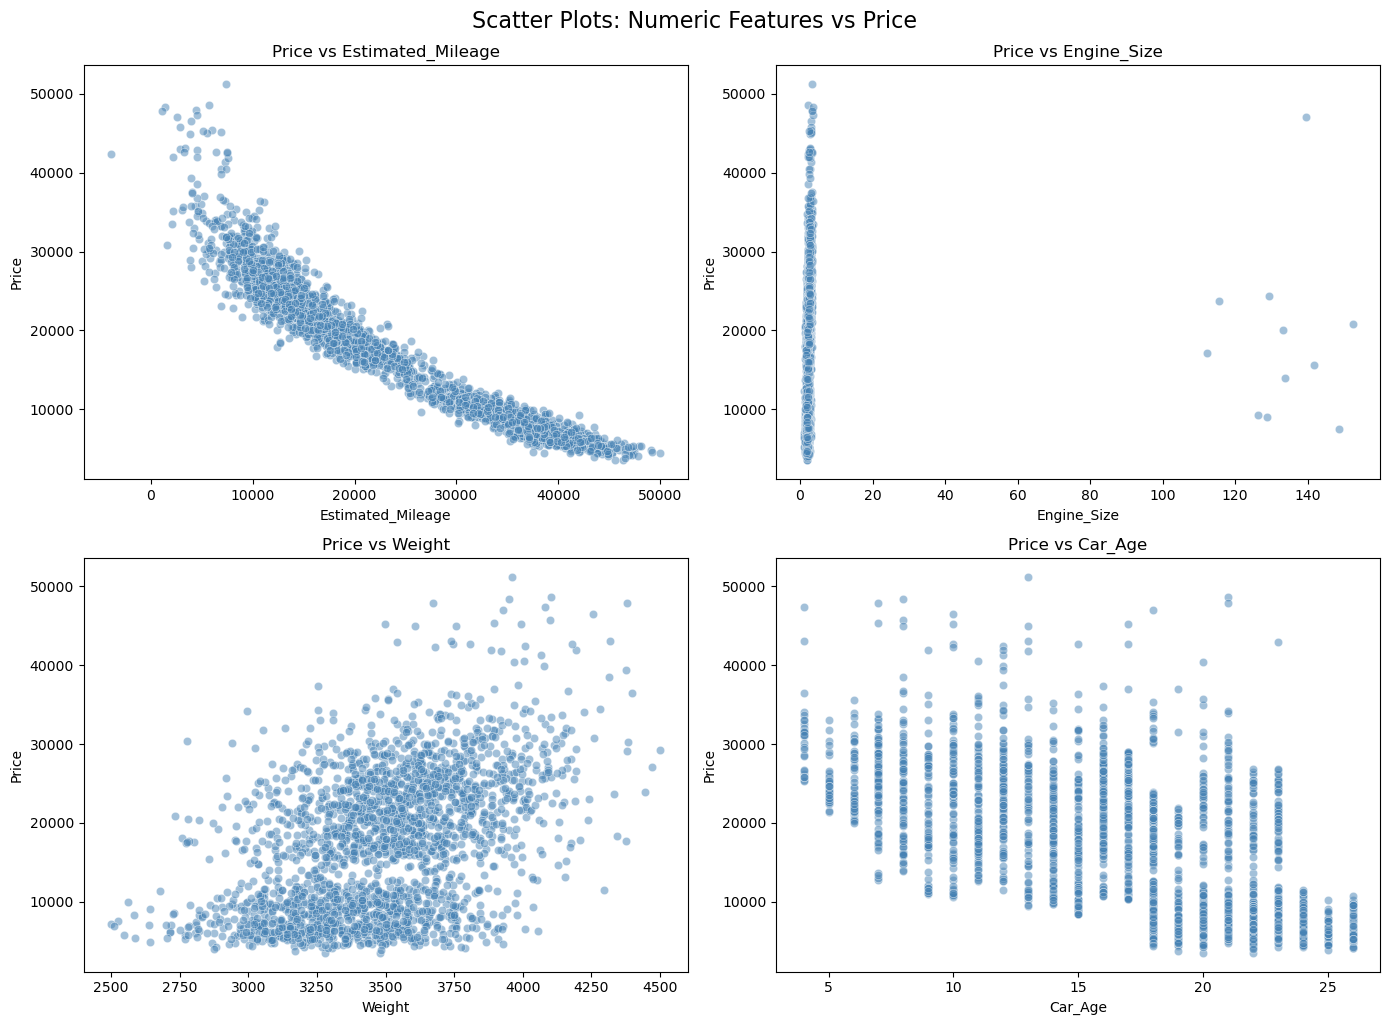

In [142]:
numeric_cols = [
    "Estimated_Mileage", "Engine_Size", "Weight",
     "Car_Age"
]

# Drop rows with missing values
df_plot = df[numeric_cols + ["Price"]].dropna()

# Create 2x2 scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(data=df_plot, x=col, y="Price", ax=axes[i], alpha=0.5, color='steelblue')
    axes[i].set_title(f"Price vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Price")

plt.tight_layout()
plt.suptitle("Scatter Plots: Numeric Features vs Price", fontsize=16, y=1.02)
plt.show()

1. Estimated_Mileage vs Price
Strong negative correlation: As mileage increases, the price sharply decreases.

This is a key predictor, indicating that more-used cars are significantly cheaper.

2. Engine_Size vs Price
The data is mostly clustered with an Engine_Size under 10, but a few extreme values above 100 distort the scale.

This suggests the presence of outliers, which are likely data errors that should be removed or capped.

The general trend is that a higher engine size relates to a higher price, but the signal is weak due to the outliers.

3. Weight vs Price
There is a mild positive trend, suggesting that heavier cars slightly correlate with a higher price.

The data has a significant spread, indicating that other variables likely moderate this effect.

4. Car_Age vs Price
There is a clear downward trend; as cars get older, the price tends to drop.

Younger cars (3-7 years old) show the highest prices, while prices for older cars (17+ years) are much lower and more compressed.

This indicates that car age is a strong, non-linear predictor of price.

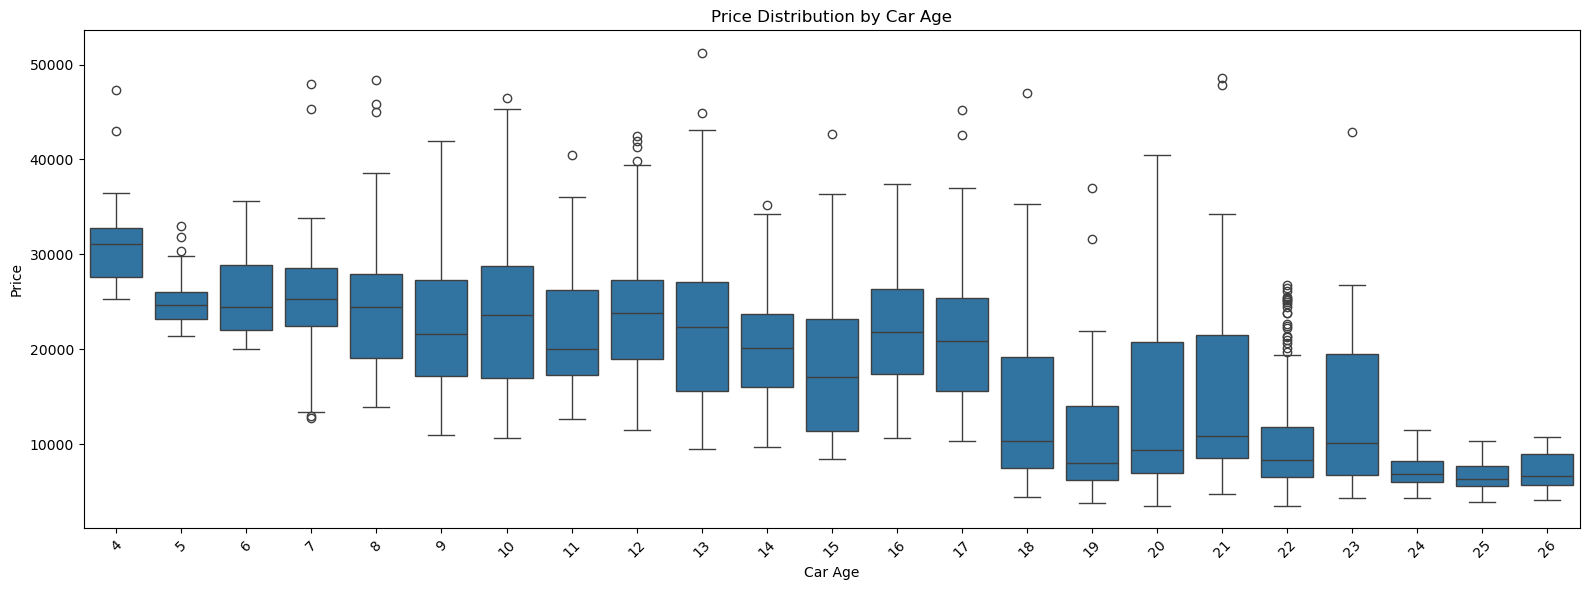

In [144]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x="Car_Age", y="Price")

plt.title("Price Distribution by Car Age")
plt.xlabel("Car Age")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Clear Downward Trend: The plot shows a strong negative relationship between car age and price. As a car gets older, its median price (the line inside each box) consistently drops.

Young Cars Hold Higher Value: Vehicles between 3 and 7 years old have the highest and most stable prices. Their median prices are consistently above 25,000.

Depreciation Plateaus for Older Cars: For cars aged 17 years and older, the prices are much lower and more compressed. The boxes are shorter, indicating less price variation among these older vehicles.

Outliers: Numerous outliers (the circles above the boxes) are present, especially for cars under 16 years old. These represent specific vehicles that are priced much higher than the typical car of the same age, likely due to low mileage, special editions, or excellent condition

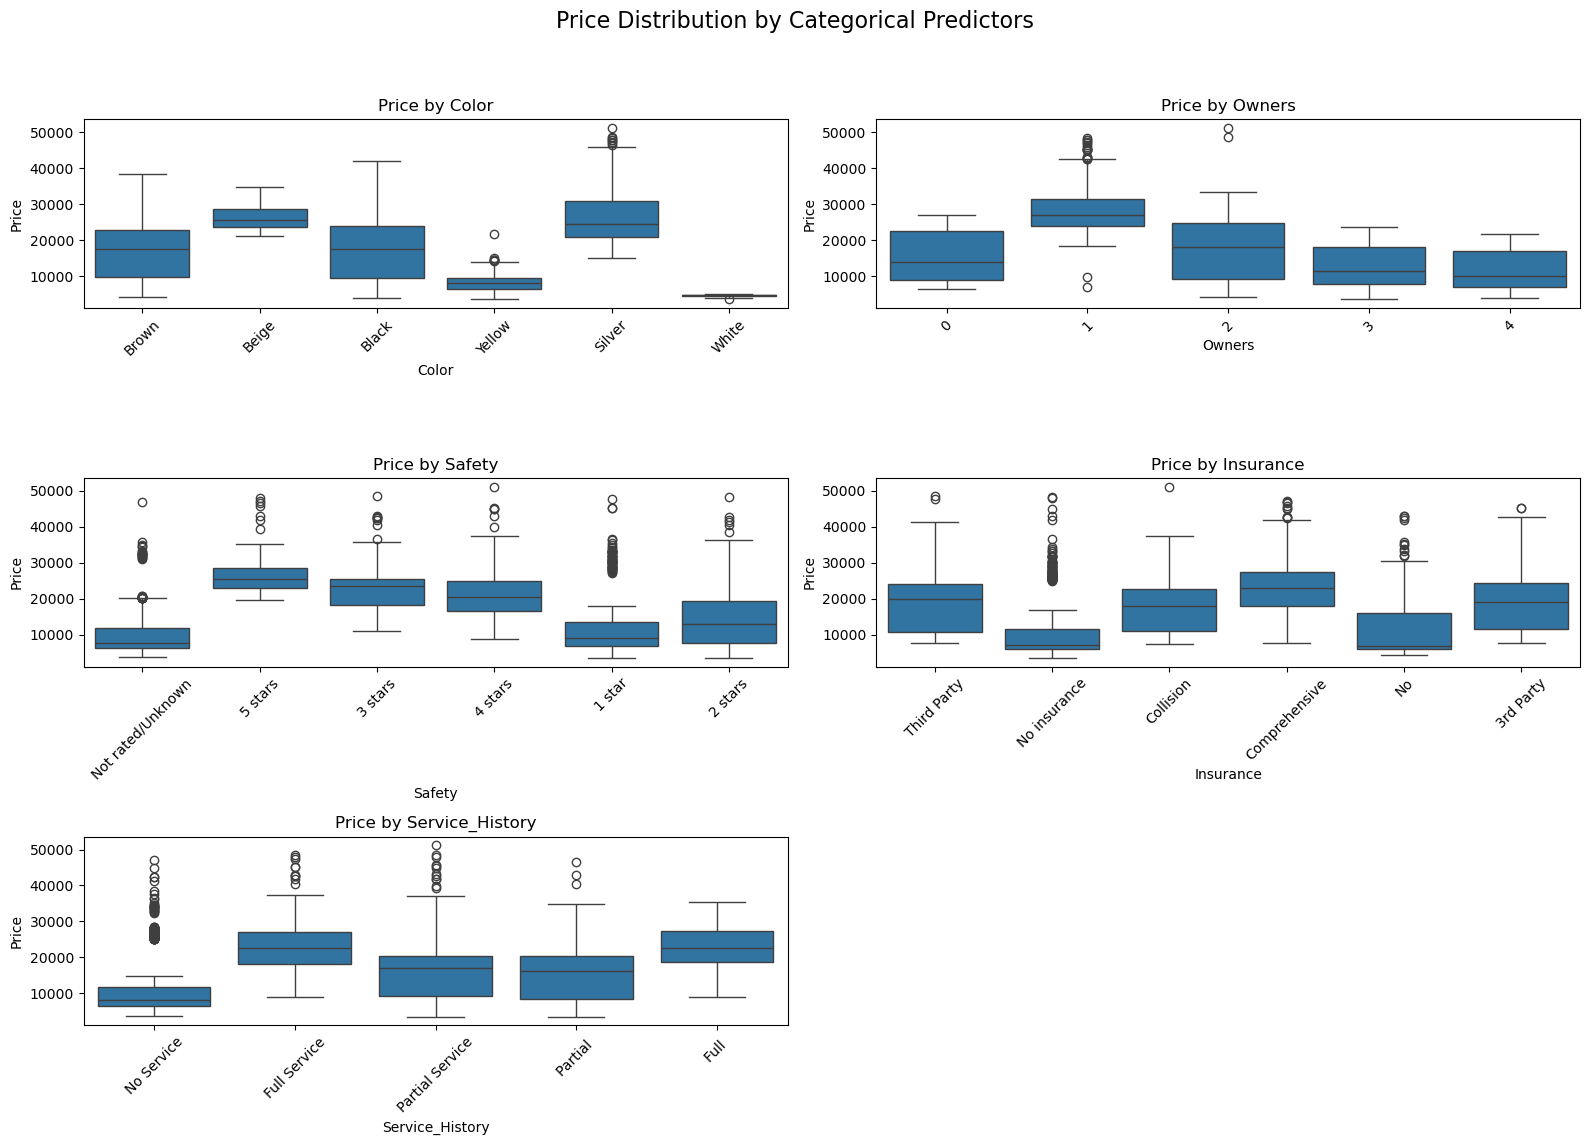

In [146]:
non_numeric_cols = ["Color", "Owners", "Safety", "Insurance", "Service_History"]

# Drop missing values
df_cat = df[non_numeric_cols + ["Price"]].dropna()

# Create 3x2 grid of boxplots
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(non_numeric_cols):
    sns.boxplot(data=df_cat, x=col, y="Price", ax=axes[i])
    axes[i].set_title(f"Price by {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra axes
for j in range(len(non_numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Price Distribution by Categorical Predictors", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Price by Color: There's no strong, predictable pattern. However, cars with "Silver" and "Beige" paint appear to have a slightly higher median price compared to other colors. Overall, color seems to have low predictive power.

Price by Owners: The median price is highest for cars with 1 previous owner and then steadily decreases as the number of owners increases. This shows a clear, logical trend and indicates that the number of owners has moderate predictive power.

Price by Safety: Higher safety ratings (e.g., "5 stars" and "3 stars") tend to have a higher median price than lower-rated cars (e.g., "1 star" and "2 stars"). The "Not rated/Unknown" category has the lowest median price. This suggests safety rating has a discernible, though not perfect, relationship with price.

Price by Insurance: Cars with "Comprehensive" insurance have a noticeably higher median price than those with other types of insurance like "Third Party" or "No Insurance". This suggests a link between vehicle value and the quality of the insurance plan.

Price by Service_History: "Full Service" history is associated with the highest median price and a wide range of values, including many high-priced outliers. Conversely, "No Service" corresponds to the lowest median price. This makes service history a strong predictor of a car's value.

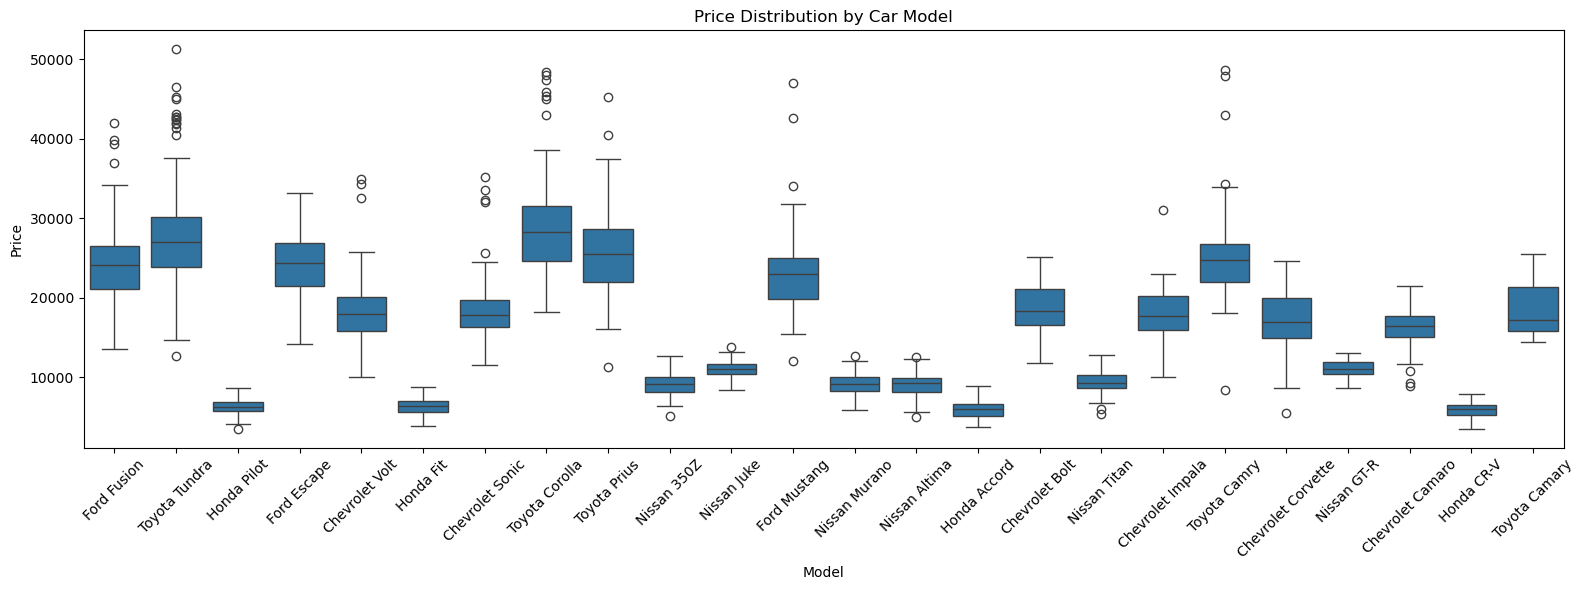

In [148]:
# Drop missing values
model = df[["Model", "Price"]].dropna()

# Plot
plt.figure(figsize=(16, 6))
sns.boxplot(data=model, x="Model", y="Price", order=model["Model"].value_counts().index)
plt.title("Price Distribution by Car Model")
plt.xticks(rotation=45)
plt.xlabel("Model")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

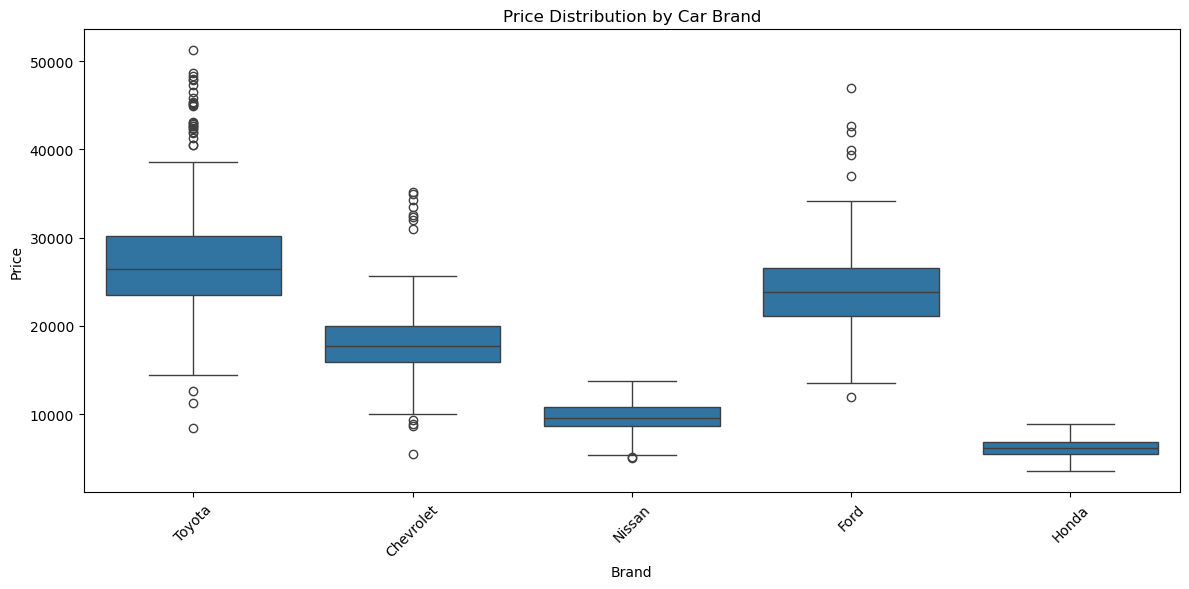

In [149]:
import seaborn as sns

# Extract brand from the model (assumes first word is the brand)
df["Brand"] = df["Model"].str.split().str[0]

# Drop missing values
brand_data = df[["Brand", "Price"]].dropna()

# Plot boxplot by brand
plt.figure(figsize=(12, 6))
sns.boxplot(data=brand_data, x="Brand", y="Price", order=brand_data["Brand"].value_counts().index)
plt.title("Price Distribution by Car Brand")
plt.xticks(rotation=45)
plt.xlabel("Brand")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### Plot 1:

- Model-Level Price Variation: The first plot shows a wide variation in price across different models.

- High-End Models: The Toyota Tundra, Toyota Corolla, and Ford Fusion show the highest median prices and the widest price ranges.

- Budget Models: Models like the Honda Fit, Nissan Altima, and Chevrolet Bolt are clustered at the lower end of the price spectrum.

- Performance Models: The Chevrolet Corvette and Nissan GT-R show a relatively high median price but a tighter price range compared to the high-end trucks and sedans.

### Plot 2:
- Brand-Level Simplification: The second plot simplifies the analysis by grouping models into brands, revealing clearer overall trends.

- Toyota and Ford have the highest median prices and the widest price distributions, reflecting their diverse range of models from budget to premium.

- Chevrolet sits in the mid-range.

- Nissan and Honda have the lowest median prices and the narrowest spreads, indicating they primarily offer budget-focused vehicles in this dataset.

-> Value of Grouping: Comparing the two plots shows the value of feature engineering. The "Model" feature has too many categories to easily interpret, while grouping into "Brand" provides a much cleaner, high-level insight into pricing trends.

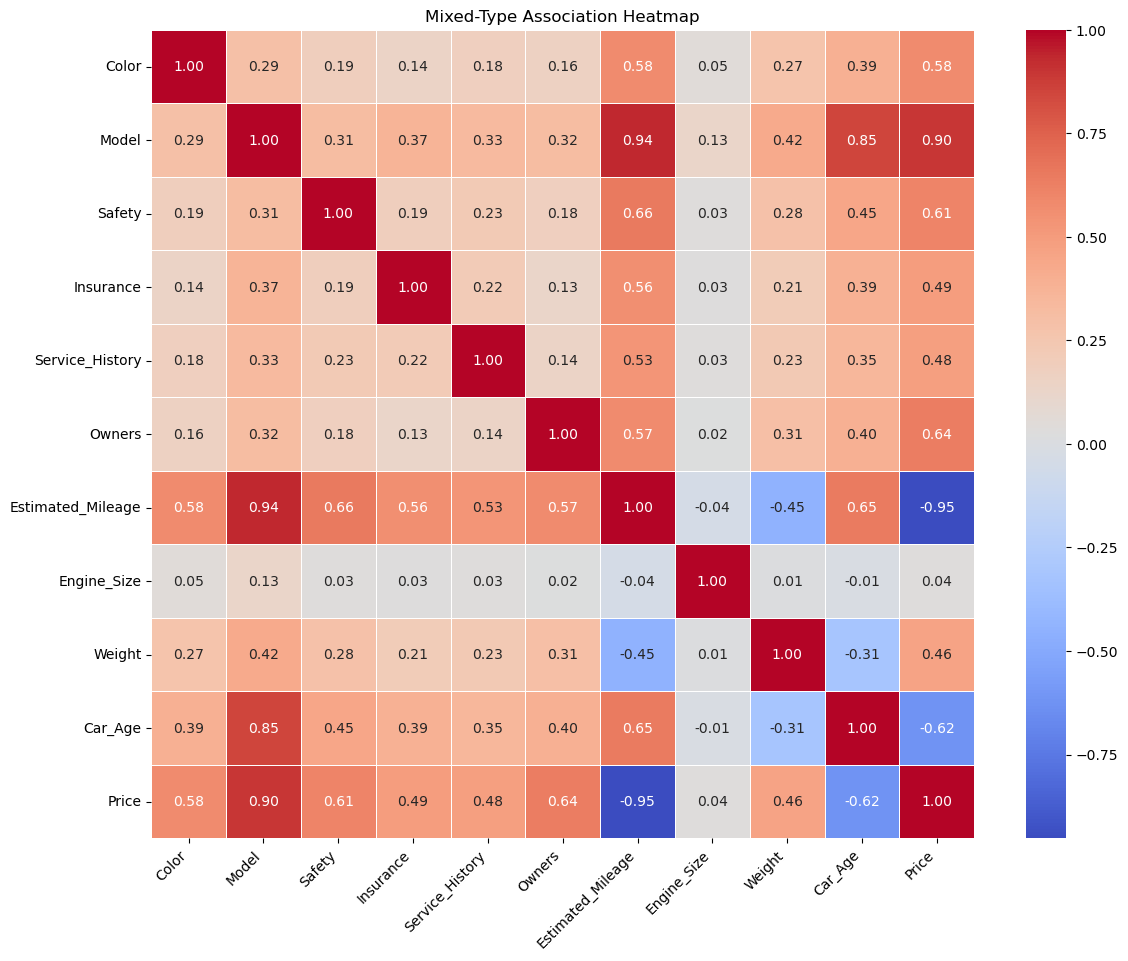

In [151]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss


def cramers_v(x, y):
    """ Calculates Cramér's V for categorical-categorical association. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    if n == 0:
        return 0
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    if min((kcorr - 1), (rcorr - 1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

def correlation_ratio(categories, measurements):
    """ Calculates the Correlation Ratio (eta) for categorical-numerical association. """
    fcat, _ = pd.factorize(categories)
    grouped = measurements.groupby(fcat)
    ss_between = np.sum(grouped.count() * (grouped.mean() - measurements.mean())**2)
    ss_total = np.sum((measurements - measurements.mean())**2)
    if ss_total == 0:
        return 0
    return np.sqrt(ss_between / ss_total)

# --- Main Script ---

# These are the lists for your top features + Price
numeric_cols = ["Estimated_Mileage", "Engine_Size", "Weight", "Car_Age", "Price"]
non_numeric_cols = ["Color", "Model", "Safety", "Insurance", "Service_History", "Owners"]

top_10_feature_names = ["Color", "Model", "Safety", "Insurance", "Service_History",
                        "Owners", "Estimated_Mileage", "Engine_Size", "Weight", "Car_Age"]

# Now, add "Price" just once to create the final list for the heatmap
heatmap_features = top_10_feature_names + ["Price"]

# Create a clean subset of the dataframe with no missing values
df_subset = df[heatmap_features].dropna()

# Initialize an empty DataFrame for the association values
assoc_matrix = pd.DataFrame(index=heatmap_features, columns=heatmap_features, dtype=float)

# Calculate the association between each pair of features
for col1 in heatmap_features:
    for col2 in heatmap_features:
        if col1 == col2:
            assoc_matrix.loc[col1, col2] = 1.0
            continue

        col1_is_numeric = col1 in numeric_cols
        col2_is_numeric = col2 in numeric_cols

        if col1_is_numeric and col2_is_numeric:
            # Numeric-Numeric: Use Pearson's Correlation
            assoc_matrix.loc[col1, col2] = df_subset[col1].corr(df_subset[col2])
        elif not col1_is_numeric and not col2_is_numeric:
            # Categorical-Categorical: Use Cramér's V
            assoc_matrix.loc[col1, col2] = cramers_v(df_subset[col1], df_subset[col2])
        else:
            # Categorical-Numeric: Use Correlation Ratio
            if col1_is_numeric:
                assoc_matrix.loc[col1, col2] = correlation_ratio(df_subset[col2], df_subset[col1])
            else:
                assoc_matrix.loc[col1, col2] = correlation_ratio(df_subset[col1], df_subset[col2])

# --- Plot the Heatmap ---
plt.figure(figsize=(12, 10))
sns.heatmap(assoc_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Mixed-Type Association Heatmap")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

## Method Justification
This Mixed-Type Association Heatmap shows relationships of all predictors and the target (Price). A standard correlation matrix is not appropriate because its calculations (typically Pearson's correlation) are only meaningful for numerical data.

- Overcomes Limitations: This method solves the problem of analyzing categorical data in a correlation-style matrix by applying the statistically correct measure for each type of variable pairing.

- Numerical vs. Numerical: For pairs like (Car_Age, Price), it uses the standard Pearson's correlation coefficient to measure the strength and direction of a linear relationship.

- Categorical vs. Categorical: For pairs like (Model, Color), it uses Cramér's V, which measures the strength of association on a scale from 0 (no association) to 1 (perfect association).

- Numerical vs. Categorical: For pairs like (Price, Model), it uses the Correlation Ratio (η), which measures how well the categorical variable explains the variance in the numerical variable, also on a scale of 0 to 1.

## Interpretation of Key Insights
- This heatmap reveals the most influential factors driving car prices and how the features relate to each other.

- Most Important Price Predictors: The strongest relationships with Price are:

- Estimated_Mileage (-0.95): This is a near-perfect negative correlation. Mileage is the single most powerful predictor; as mileage goes up, price goes down very consistently.

- Model (0.90): This is an extremely strong positive association. The specific model of a car is a top indicator of its price, meaning certain models are reliably more expensive than others.

- Car_Age (-0.62): A strong negative correlation. As expected, older cars are cheaper.

Other Significant Relationships:

- Model and Estimated_Mileage (0.94): The model of a car is strongly associated with its mileage. This suggests certain models are typically driven more (or less) than others.

- Model and Car_Age (0.85): There's a strong link between a car's model and its age, likely because some models are older or newer in this specific dataset.

- Car_Age and Estimated_Mileage (0.65): A moderately strong positive correlation shows that, logically, older cars tend to have higher mileage.

# Multivariate Analysis

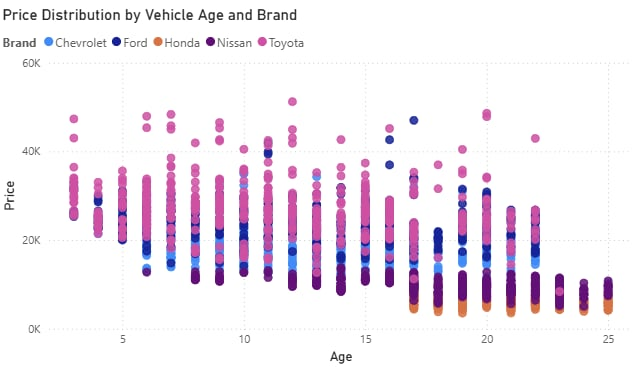

Here's a more concise interpretation of the graph:

* **Impact of Vehicle Age:**: The strongest trend is that all cars lose value as they get older, with the steepest price drop occurring in the first few years.

* **Brands Have Tiers**: Each brand fits into a clear price category. Toyota and Ford offer the most expensive, high-end models, while Honda and Nissan are consistently in the lower, budget-friendly range.

* **High-Value Outliers**: Some older Ford and Chevrolet models retain unusually high prices, likely representing classic or special-edition vehicles that hold their value well.

#### HANDLE MISSING VALUES

In [158]:
df_features = df[top_10_feature_names + ["Price"]].copy()

In [159]:
df_features.isnull().sum()

Color                2
Model                0
Safety               0
Insurance            0
Service_History      0
Owners               0
Estimated_Mileage    0
Engine_Size          0
Weight               3
Car_Age              0
Price                0
dtype: int64

In [160]:
# Convert to numeric format
df_features["Estimated_Mileage"] = pd.to_numeric(df_features["Estimated_Mileage"], errors="coerce")
df_features["Weight"] = pd.to_numeric(df_features["Weight"], errors="coerce")

# Handle missing values
# For categorical variables → use mode
categorical_cols = ["Color", "Safety"]
for col in categorical_cols:
    df_features[col] = df_features[col].fillna(df_features[col].mode()[0])

# For numeric variables → use median
numeric_cols = ["Weight"]
for col in numeric_cols:
    df_features[col] = df_features[col].fillna(df_features[col].median())

#  Check data
print("Remaining missing values:\n", df_features.isnull().sum())

Remaining missing values:
 Color                0
Model                0
Safety               0
Insurance            0
Service_History      0
Owners               0
Estimated_Mileage    0
Engine_Size          0
Weight               0
Car_Age              0
Price                0
dtype: int64


#### LABEL ENCODING

In [162]:
# label encoding for data
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Model", "Safety", "Insurance", "Service_History", "Color"]

for col in categorical_cols:
    le = LabelEncoder()
    df_features[col] = le.fit_transform(df_features[col])

#### HANDLE OUTLIER

In [164]:
from sklearn.ensemble import IsolationForest

# Split features and target
X = df_features.drop(columns=["Price"])
y = df_features["Price"]

# Fit Isolation Forest
clf = IsolationForest(n_estimators=100, contamination=0.03, random_state=7)
clf.fit(X)

# Predict outlier labels (outlier = -1, normal = 1)
yhat = clf.predict(X)

# Keep only the normal observations
X_filtered = X[yhat == 1]
y_filtered = y[yhat == 1]

# Combine back into a cleaned DataFrame
df_features_cleaned = X_filtered.copy()
df_features_cleaned["Price"] = y_filtered

In [165]:
print("Original number of rows:", df_features.shape[0])
print("Number of rows after outlier removal:", df_features_cleaned.shape[0])
print("Total outliers removed:", df.shape[0] - df_features_cleaned.shape[0])

Original number of rows: 2230
Number of rows after outlier removal: 2163
Total outliers removed: 67


In [166]:
print(df_features_cleaned.dtypes)
print(df_features_cleaned.shape)

Color                  int32
Model                  int32
Safety                 int32
Insurance              int32
Service_History        int32
Owners                 int64
Estimated_Mileage    float64
Engine_Size          float64
Weight               float64
Car_Age                int64
Price                float64
dtype: object
(2163, 11)


In [167]:
df_features_cleaned

,Color,Model,Safety,Insurance,Service_History,Owners,Estimated_Mileage,Engine_Size,Weight,Car_Age,Price
0,2,14,5,5,2,2,36245.69700,1.655688,3170.460434,19,8005.469674
1,0,21,4,4,1,1,10736.91127,2.696626,3543.006290,7,25385.241860
2,2,10,5,4,2,4,41953.92523,1.642471,3125.542396,22,6553.601733
3,2,21,2,1,1,1,12446.97569,2.044309,3340.060049,6,24381.083350
4,2,23,4,2,4,1,10560.54904,2.586011,3847.825597,9,28357.830640
...,...,...,...,...,...,...,...,...,...,...,...
2225,3,4,1,2,1,4,24612.10317,2.238645,4157.519949,13,15164.228470
2226,1,11,5,4,4,2,35581.95722,2.283821,3058.960939,19,6250.307375
2227,5,4,3,5,1,1,15609.82872,2.355598,3503.415954,14,21614.535620
2228,2,18,0,1,2,3,36638.12130,1.944553,3748.991341,23,8373.305539


In [168]:
# Export the cleaned DataFrame to an Excel file
output_path = "car_data_cleaned.csv"  # or use full path if needed
df_features_cleaned.to_csv(output_path, index=False)

print(f"✅ Excel file has been saved as: {output_path}")

✅ Excel file has been saved as: car_data_cleaned.csv


# Model Development

## Splitting Training data and testing data

In [171]:
from sklearn.model_selection import train_test_split

In [172]:
df_final = pd.read_excel('car_data_cleaned.xlsx') 

In [173]:
X = df_final.drop('Price', axis = 1)
y = df_final['Price']

In [174]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5)

## Baseline Model

Mean is used for baseline performance

In [177]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

In [178]:
dummy = DummyRegressor(strategy = 'mean')
baseline_model = dummy.fit(X_train, y_train)

yhat_dummy = baseline_model.predict(X_train)
mse_train_dummy = mean_squared_error(y_train, yhat_dummy)
rmse_train_dummy = np.sqrt(mse_train_dummy)

print(f'MSE Training = {mse_train_dummy}')
print(f'RMSE Training = {rmse_train_dummy}')

MSE Training = 75332202.00878444
RMSE Training = 8679.412538230017


The mean was used to get baseline predictions. This shows extremely high MSE and RMSE values which suggests this is a poor prediction

## 1. Linear Regression

In [181]:
# For linear regression, we need to do one hot encoding
# We first create a duplicate dataset
X_train_binary = X_train.copy()
X_test_binary = X_test.copy()

In [182]:
# Creating dummy variables for use in models that require dummies

# Importing the relevant library
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(drop = 'first', sparse_output = False)

# Defining categorical columns
cat_columns = ["Model", "Safety", "Insurance", "Service_History", "Color"]

# Making dummy variables
cat_values_train = X_train_binary[cat_columns].to_numpy()
transformed_train = one_hot_encoder.fit_transform(cat_values_train)

# Giving these new columns names
new_col_names = one_hot_encoder.get_feature_names_out(cat_columns)

# Creating a new dataframe for the dummy variables
encoded_train = pd.DataFrame(transformed_train, columns = new_col_names, index = X_train_binary.index)

# Dropping the old columns which are not converted to binary and join the new columns
X_train_binary.drop(columns = cat_columns, inplace = True)
X_train_binary = pd.concat([X_train_binary, encoded_train], axis = 1)

In [183]:
# Applying the same encoding to the test set
cat_values_test = X_test_binary[cat_columns].to_numpy()
transformed_test = one_hot_encoder.transform(cat_values_test)

# Creating new dataframe for test set dummy variables
encoded_test = pd.DataFrame(transformed_test, columns = new_col_names, index = X_test_binary.index)

# Dropping old columns from test set and joining new columns
X_test_binary.drop(columns = cat_columns, inplace = True)
X_test_binary = pd.concat([X_test_binary, encoded_test], axis = 1)

In [184]:
# Doing linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_binary, y_train)

yhat_train = model.predict(X_train_binary)
yhat_test = model.predict(X_test_binary)

mse_train = mean_squared_error(y_train, yhat_train)
mse_test = mean_squared_error(y_test, yhat_test)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print(f'Training data MSE = {mse_train}')
print(f'Testing data MSE = {mse_test}')
print(f'Training data RMSE = {rmse_train}')
print(f'Testing data RMSE = {rmse_test}')

Training data MSE = 4690871.7294374695
Testing data MSE = 4934717.150663704
Training data RMSE = 2165.842037046439
Testing data RMSE = 2221.4223260478193


Linear regression provides an obvious imporvement from the baseline, but there is still room for improvement

## 2. Decision Trees

In [187]:
!pip install tabulate
from tabulate import tabulate

In [188]:
!pip install scikit-optimize
from skopt import BayesSearchCV

In [189]:
from sklearn.tree import DecisionTreeRegressor

In [190]:
hp_sets = [
    {'max_depth': 5, 'min_samples_split': 20},
    {'max_depth': 10, 'min_samples_split': 20},
    {'max_depth': 5, 'min_samples_split': 10},
    {'max_depth': 10, 'min_samples_split': 10},
    {'max_depth': 15, 'min_samples_split': 10},
    {'max_depth': 15, 'min_samples_split': 20},
]

# Save results in list
results = []

# Loop to run over each hp set
for idx, params in enumerate(hp_sets, 1):
    
    #Train model
    model = DecisionTreeRegressor(**params, random_state=5)
    model.fit(X_train_binary, y_train)
    
    #predict on train and test sets
    yhat_train = model.predict(X_train_binary)
    yhat_test = model.predict(X_test_binary)
    
    # MSE
    mse_train = mean_squared_error(y_train, yhat_train)
    mse_test = mean_squared_error(y_test, yhat_test)
    
    #rmse
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    
    # results save
    results.append(
        {
            'Model': f'Model {idx}',
            'Params': params,
            'MSE Train': round(mse_train, 2),
            'MSE Test': round(mse_test, 2),
            'RMSE Train': round(rmse_train, 2),
            'RMSE Test': round(rmse_test, 2)
        }
    )

#Create results df
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('RMSE Test', ascending=True)
print(tabulate(results_df_sorted, headers='keys', tablefmt='psql'))

+----+---------+--------------------------------------------+------------------+-------------+--------------+-------------+
|    | Model   | Params                                     |        MSE Train |    MSE Test |   RMSE Train |   RMSE Test |
|----+---------+--------------------------------------------+------------------+-------------+--------------+-------------|
|  0 | Model 1 | {'max_depth': 5, 'min_samples_split': 20}  |      3.0595e+06  | 4.92975e+06 |      1749.14 |     2220.3  |
|  2 | Model 3 | {'max_depth': 5, 'min_samples_split': 10}  |      3.0595e+06  | 4.92975e+06 |      1749.14 |     2220.3  |
|  1 | Model 2 | {'max_depth': 10, 'min_samples_split': 20} |      1.7613e+06  | 5.49864e+06 |      1327.14 |     2344.92 |
|  5 | Model 6 | {'max_depth': 15, 'min_samples_split': 20} |      1.48111e+06 | 5.59675e+06 |      1217.01 |     2365.75 |
|  3 | Model 4 | {'max_depth': 10, 'min_samples_split': 10} |      1.29113e+06 | 6.06904e+06 |      1136.28 |     2463.54 |
|  4 | M

Model with a depth of 10 and 20 min samples split is the best with the lowest RMSE.
The RMSE is also significantly lower than the baseline suggestinf performance improvement

## 3. Random Forest

In [193]:
from sklearn.ensemble import RandomForestRegressor

In [194]:
hp_sets = [
    {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 20},
    {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 20},
    {'n_estimators': 30, 'max_depth': 5, 'min_samples_split': 20},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 20},
    {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 20},
    {'n_estimators': 30, 'max_depth': 10, 'min_samples_split': 20},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10},
    {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 10},
    {'n_estimators': 30, 'max_depth': 10, 'min_samples_split': 10},
]

# Save results in list
results = []

# Loop to run over each hp set
for idx, params in enumerate(hp_sets, 1):
    
    #Train model
    model = RandomForestRegressor(**params, random_state=5)
    model.fit(X_train, y_train)
    
    #predict on train and test sets
    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)
    
    # MSE
    mse_train = mean_squared_error(y_train, yhat_train)
    mse_test = mean_squared_error(y_test, yhat_test)
    
    #rmse
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    
    # results save
    results.append(
        {
            'Model': f'Model {idx}',
            'Params': params,
            'MSE Train': round(mse_train, 2),
            'MSE Test': round(mse_test, 2),
            'RMSE Train': round(rmse_train, 2),
            'RMSE Test': round(rmse_test, 2)
        }
    )

#Create results df
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('RMSE Test', ascending=True)
print(tabulate(results_df_sorted, headers='keys', tablefmt='psql'))

+----+---------+-----------------------------------------------------------------+-------------+-------------+--------------+-------------+
|    | Model   | Params                                                          |   MSE Train |    MSE Test |   RMSE Train |   RMSE Test |
|----+---------+-----------------------------------------------------------------+-------------+-------------+--------------+-------------|
|  3 | Model 4 | {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 20} | 1.81091e+06 | 3.12116e+06 |      1345.7  |     1766.68 |
|  4 | Model 5 | {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 20}  | 1.8417e+06  | 3.20971e+06 |      1357.09 |     1791.57 |
|  5 | Model 6 | {'n_estimators': 30, 'max_depth': 10, 'min_samples_split': 20}  | 1.85408e+06 | 3.22052e+06 |      1361.65 |     1794.58 |
|  6 | Model 7 | {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 10} | 1.23811e+06 | 3.22774e+06 |      1112.71 |     1796.59 |
|  8 | Model 9 | {'n

Again, a significant improvement was soon on the RMSE values of the test set suggesting random forest is better

## 4. ANN

In [197]:
from sklearn.neural_network import MLPRegressor

In [198]:
hp_sets = [
    {'hidden_layer_sizes': 100, 'activation': 'identity'},
    {'hidden_layer_sizes': 50, 'activation': 'identity'},
    {'hidden_layer_sizes': 100, 'activation': 'relu'},
    {'hidden_layer_sizes': 50, 'activation': 'relu'},
    {'hidden_layer_sizes': 100, 'activation': 'logistic'},
    {'hidden_layer_sizes': 50, 'activation': 'logistic'},
    {'hidden_layer_sizes': 100, 'activation': 'tanh'},
    {'hidden_layer_sizes': 50, 'activation': 'tanh'},
    {'hidden_layer_sizes': (100,50), 'activation': 'identity'},
    {'hidden_layer_sizes': (200,100), 'activation': 'identity'},
    {'hidden_layer_sizes': (100,50), 'activation': 'relu'},
    {'hidden_layer_sizes': (200,100), 'activation': 'relu'},
    {'hidden_layer_sizes': (100,50), 'activation': 'logistic'},
    {'hidden_layer_sizes': (200,100), 'activation': 'logistic'},
    {'hidden_layer_sizes': (100,50), 'activation': 'tanh'},
    {'hidden_layer_sizes': (200,100), 'activation': 'tanh'}
]

# Save results in list
results = []

# Loop to run over each hp set
for idx, params in enumerate(hp_sets, 1):
    
    #Train model
    model = MLPRegressor(**params, random_state=5)
    model.fit(X_train, y_train)
    
    #predict on train and test sets
    yhat_train = model.predict(X_train)
    yhat_test = model.predict(X_test)
    
    # MSE
    mse_train = mean_squared_error(y_train, yhat_train)
    mse_test = mean_squared_error(y_test, yhat_test)
    
    #rmse
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    
    # results save
    results.append(
        {
            'Model': f'Model {idx}',
            'Params': params,
            'MSE Train': round(mse_train, 2),
            'MSE Test': round(mse_test, 2),
            'RMSE Train': round(rmse_train, 2),
            'RMSE Test': round(rmse_test, 2)
        }
    )

#Create results df
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('RMSE Test', ascending=True)
print(tabulate(results_df_sorted, headers='keys', tablefmt='psql'))

+----+----------+--------------------------------------------------------------+-------------+-------------+--------------+-------------+
|    | Model    | Params                                                       |   MSE Train |    MSE Test |   RMSE Train |   RMSE Test |
|----+----------+--------------------------------------------------------------+-------------+-------------+--------------+-------------|
|  2 | Model 3  | {'hidden_layer_sizes': 100, 'activation': 'relu'}            | 8.51646e+06 | 7.72636e+06 |      2918.3  |     2779.63 |
| 10 | Model 11 | {'hidden_layer_sizes': (100, 50), 'activation': 'relu'}      | 8.46259e+06 | 7.74715e+06 |      2909.05 |     2783.37 |
| 11 | Model 12 | {'hidden_layer_sizes': (200, 100), 'activation': 'relu'}     | 8.65173e+06 | 7.85763e+06 |      2941.38 |     2803.15 |
|  3 | Model 4  | {'hidden_layer_sizes': 50, 'activation': 'relu'}             | 8.76763e+06 | 7.9501e+06  |      2961.02 |     2819.59 |
|  0 | Model 1  | {'hidden_layer_s

## 5. Bagging Neural network

Since ensemble techniques are showing improvements, we try to use bagging neural networks

In [201]:
from sklearn.ensemble import BaggingRegressor


base_nn = MLPRegressor(hidden_layer_sizes=100,  
                       activation='relu',
                       learning_rate_init=0.01,
                       max_iter=500,
                       random_state=42)

# Define bagging regressor using the neural network
bagging_nn = BaggingRegressor(estimator=base_nn,
                              n_estimators=10,  # Number of neural networks
                              max_samples=0.8,  # Use 80% of training data for each NN
                              bootstrap=True,
                              random_state=42)

# Train the bagging neural network
bagging_nn.fit(X_train, y_train)

# Predict
yhat_train = bagging_nn.predict(X_train)
yhat_test = bagging_nn.predict(X_test)

# Evaluate
mse_train = mean_squared_error(y_train, yhat_train)
mse_test = mean_squared_error(y_test, yhat_test)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print(f"Train MSE: {mse_train:.2f}")
print(f"Test MSE: {mse_test:.2f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE: {rmse_test:.2f}")

Train MSE: 8386082.07
Test MSE: 7533717.94
Train RMSE: 2895.87
Test RMSE: 2744.76


This shows improvement from the normal neural network but still not as good as random forest and CATBoost models